In [1]:
import os
import re
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics import r2_score

In [2]:
uth = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_uthealth-08182025.csv", index_col = 0)
gse = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00RetrainedPredictions_gse102556-08172025.csv", index_col = 0)

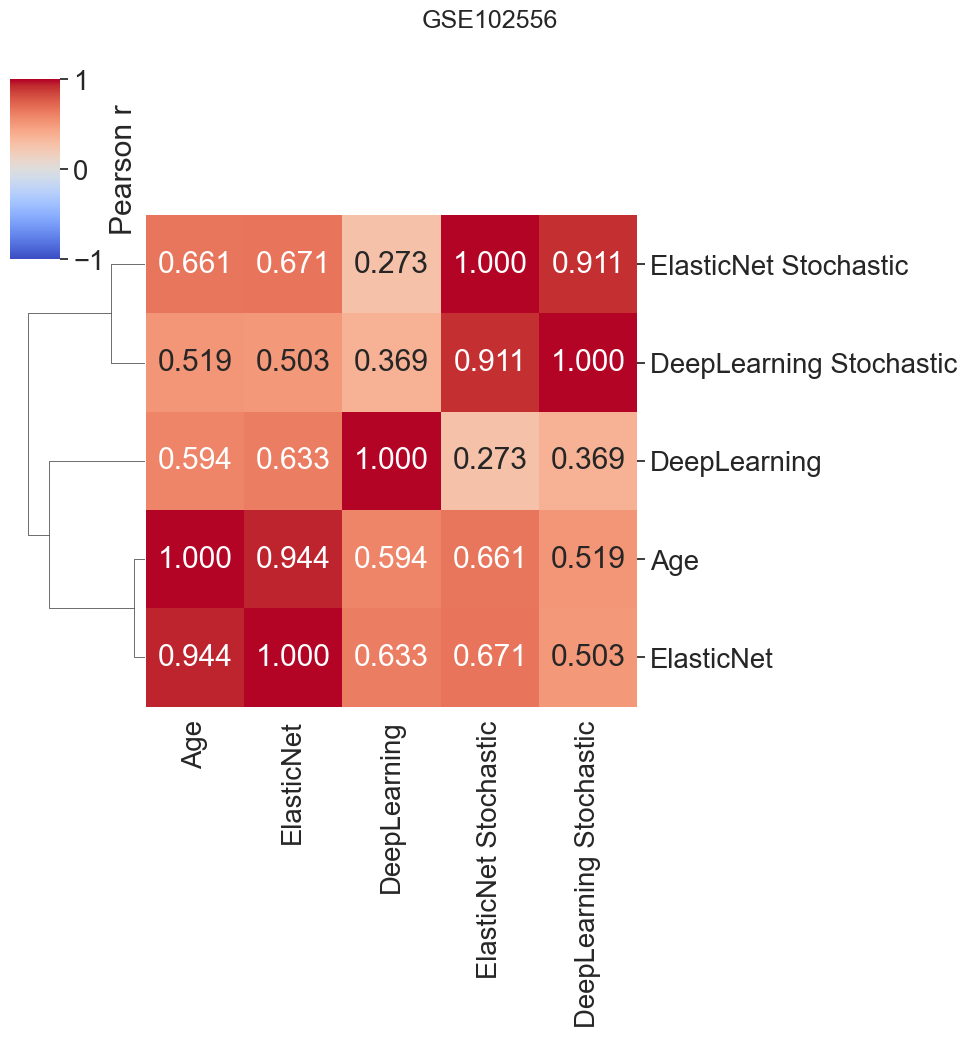

In [4]:
# ------------------------------
# Clean column names
# ------------------------------
corr_matrix = gse.corr()

# Clean labels
clean_labels = [
    col.replace("Predicted_", "").replace("Actual_", "").replace("_", " ")
    for col in corr_matrix.columns
]
corr_matrix.columns = clean_labels
corr_matrix.index = clean_labels  # also rename index for proper labels

# ------------------------------
# Plot clustermap (hierarchical clustering)
# ------------------------------
sns.set(font_scale=1.8)  # increase font
cg = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    figsize=(10,10),
    row_cluster=True,  # hierarchical clustering rows
    col_cluster=False,  # hierarchical clustering columns
    dendrogram_ratio=(0.2, 0.2),  # space for dendrograms
    cbar_kws={"label": "Pearson r"}
)

# Add title
plt.suptitle("GSE102556", fontsize=18, y=1.05)  # y>1 moves it above the plot
# Save figure
plt.savefig("00clock_correlations-08272025_clustermap.pdf", dpi=600, bbox_inches="tight")
plt.show()

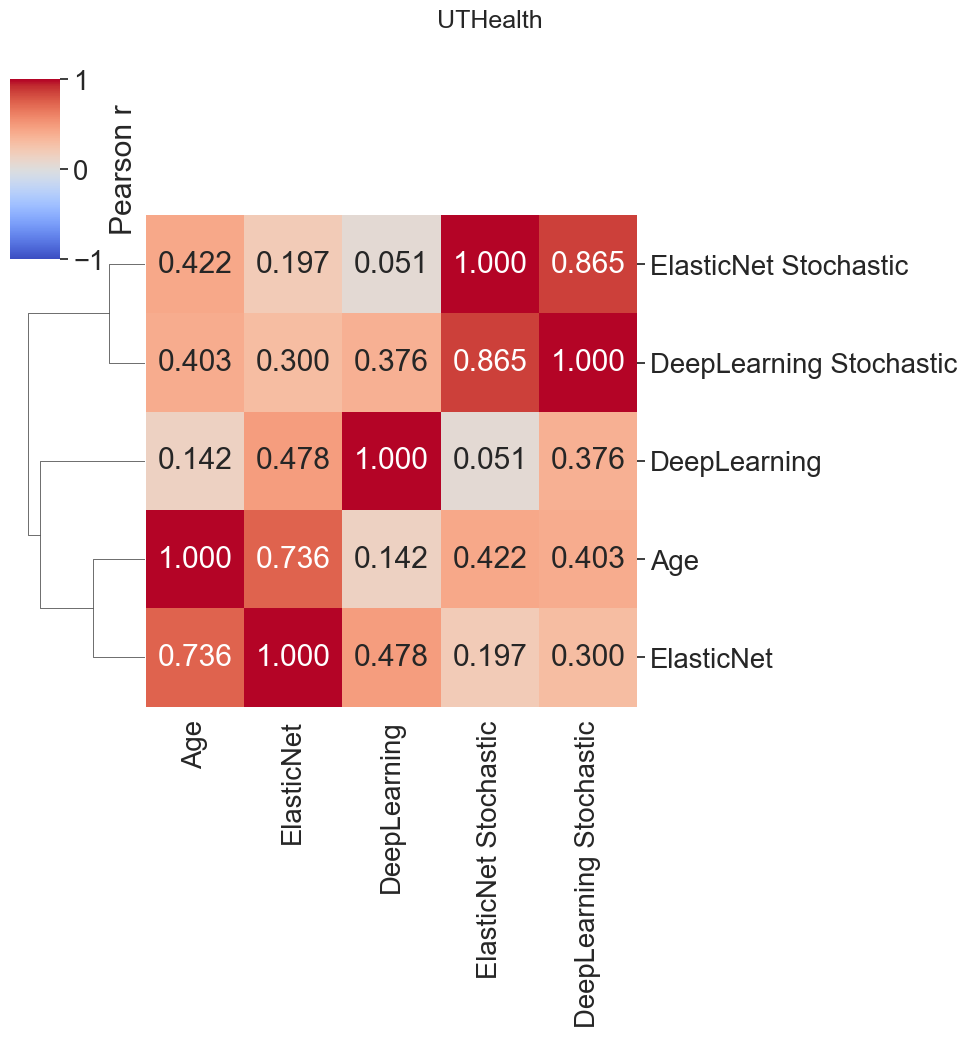

In [5]:
# ------------------------------
# Clean column names
# ------------------------------
corr_matrix = uth.corr()

# Clean labels
clean_labels = [
    col.replace("Predicted_", "").replace("Actual_", "").replace("_", " ")
    for col in corr_matrix.columns
]
corr_matrix.columns = clean_labels
corr_matrix.index = clean_labels  # also rename index for proper labels

# ------------------------------
# Plot clustermap (hierarchical clustering)
# ------------------------------
sns.set(font_scale=1.8)  # increase font
cg = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    figsize=(10,10),
    row_cluster=True,  # hierarchical clustering rows
    col_cluster=False,  # hierarchical clustering columns
    dendrogram_ratio=(0.2, 0.2),  # space for dendrograms
    cbar_kws={"label": "Pearson r"}
)

# Add title
plt.suptitle("UTHealth", fontsize=18, y=1.05)  # y>1 moves it above the plot
# Save figure
plt.savefig("00clock_correlations_UTHealth-08272025_clustermap.pdf", dpi=600, bbox_inches="tight")
plt.show()

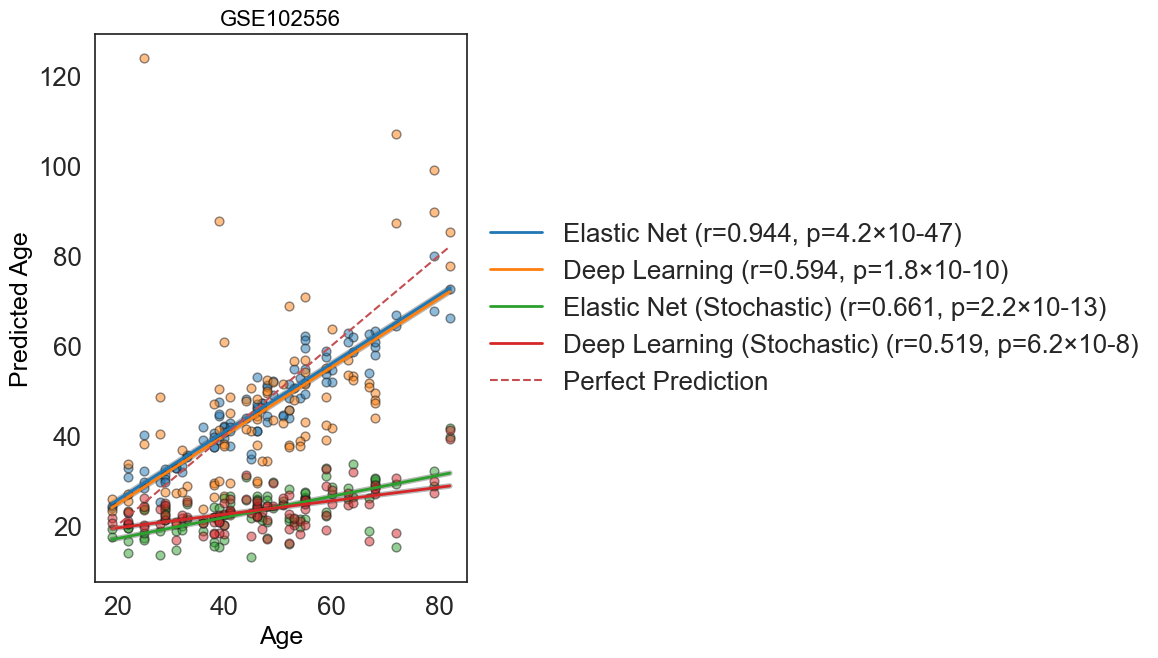

In [6]:
# ------------------------------
# Helper for pretty scientific notation
# ------------------------------
def sci_notation(p, decimals=1):
    """Format p-value in scientific notation like 2.6×10⁻⁶"""
    if p == 0:
        return "0"
    exp_str = f"{p:.{decimals}e}"  # e.g., "2.6e-06"
    base, exp = exp_str.split("e")
    return f"{base}×10{int(exp)}"

# ------------------------------
# Compute correlations + p-values
# ------------------------------
df_merge = gse
r_en, p_en = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet"])
r_dl, p_dl = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning"])
r_en_st, p_en_st = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet_Stochastic"])
r_dl_st, p_dl_st = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning_Stochastic"])

# ------------------------------
# Plot setup
# ------------------------------
sns.set_style("white")           # background
sns.set_context("notebook", font_scale=1.7)  # increase font sizes by 70%
fig, ax = plt.subplots(figsize=(12,7))

colors = {
    "ElasticNet": "tab:blue",
    "DeepLearning": "tab:orange",
    "ElasticNet_Stochastic": "tab:green",
    "DeepLearning_Stochastic": "tab:red"
}

# --- Helper: scatter + regression line with shadow ---
def scatter_with_line(x, y, color, label, r, p):
    # Scatter
    ax.scatter(x, y, alpha=0.5, edgecolor="k", color=color, s=40)

    # Regression line
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept

    # Shadow
    ax.plot(line_x, line_y, color="k", linewidth=4, alpha=0.3, zorder=1)
    # Actual line
    ax.plot(line_x, line_y, color=color, linewidth=2, zorder=2,
            label=f"{label} (r={r:.3f}, p={sci_notation(p)})")

# Plot each clock
scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet"],
                  colors["ElasticNet"], "Elastic Net", r_en, p_en)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning"],
                  colors["DeepLearning"], "Deep Learning", r_dl, p_dl)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet_Stochastic"],
                  colors["ElasticNet_Stochastic"], "Elastic Net (Stochastic)", r_en_st, p_en_st)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning_Stochastic"],
                  colors["DeepLearning_Stochastic"], "Deep Learning (Stochastic)", r_dl_st, p_dl_st)

# Perfect prediction line
min_age, max_age = df_merge["Actual_Age"].min(), df_merge["Actual_Age"].max()
ax.plot([min_age, max_age], [min_age, max_age], "r--", label="Perfect Prediction")

# Labels
ax.set_xlabel("Age", fontsize=18, color="black")
ax.set_ylabel("Predicted Age", fontsize=18, color="black")
ax.set_title("GSE102556", fontsize=16, color="black")

# Legend outside
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

# Remove grid
ax.grid(False)

plt.tight_layout()
plt.savefig("00clock_correlations-08272025.pdf", dpi=600, bbox_inches="tight")  # vector
plt.show()

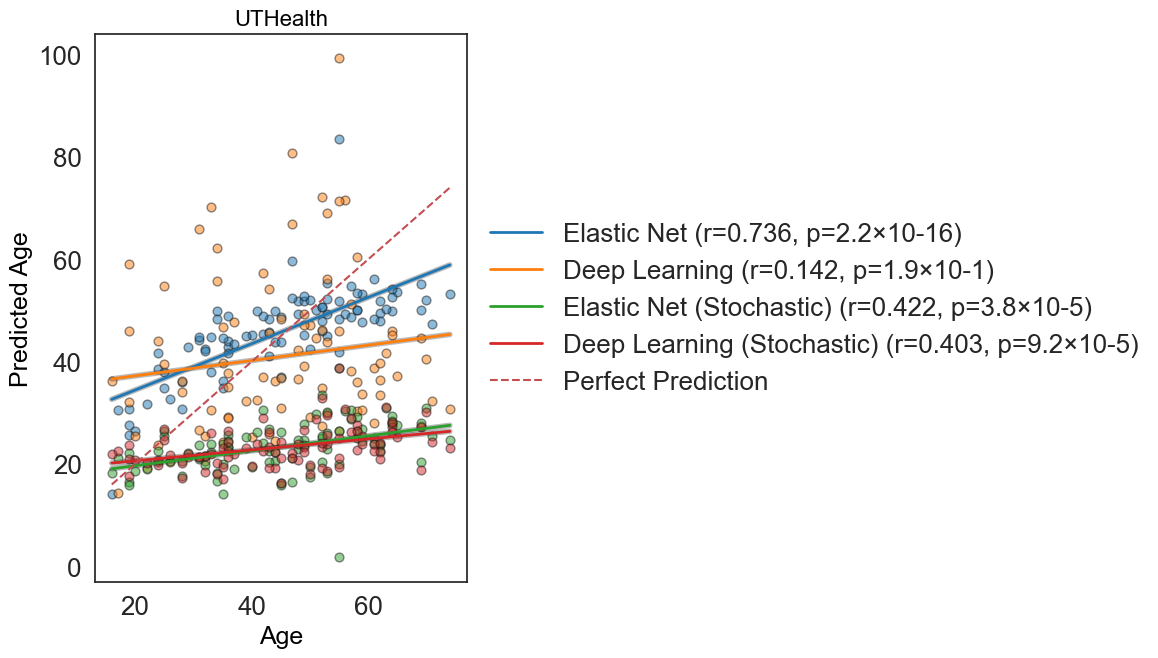

In [7]:
# ------------------------------
# Helper for pretty scientific notation
# ------------------------------
def sci_notation(p, decimals=1):
    """Format p-value in scientific notation like 2.6×10⁻⁶"""
    if p == 0:
        return "0"
    exp_str = f"{p:.{decimals}e}"  # e.g., "2.6e-06"
    base, exp = exp_str.split("e")
    return f"{base}×10{int(exp)}"

# ------------------------------
# Compute correlations + p-values
# ------------------------------
df_merge = uth
r_en, p_en = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet"])
r_dl, p_dl = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning"])
r_en_st, p_en_st = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet_Stochastic"])
r_dl_st, p_dl_st = stats.pearsonr(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning_Stochastic"])

# ------------------------------
# Plot setup
# ------------------------------
sns.set_style("white")           # background
sns.set_context("notebook", font_scale=1.7)  # increase font sizes by 70%
fig, ax = plt.subplots(figsize=(12,7))

colors = {
    "ElasticNet": "tab:blue",
    "DeepLearning": "tab:orange",
    "ElasticNet_Stochastic": "tab:green",
    "DeepLearning_Stochastic": "tab:red"
}

# --- Helper: scatter + regression line with shadow ---
def scatter_with_line(x, y, color, label, r, p):
    # Scatter
    ax.scatter(x, y, alpha=0.5, edgecolor="k", color=color, s=40)

    # Regression line
    slope, intercept = np.polyfit(x, y, 1)
    line_x = np.linspace(x.min(), x.max(), 100)
    line_y = slope * line_x + intercept

    # Shadow
    ax.plot(line_x, line_y, color="k", linewidth=4, alpha=0.3, zorder=1)
    # Actual line
    ax.plot(line_x, line_y, color=color, linewidth=2, zorder=2,
            label=f"{label} (r={r:.3f}, p={sci_notation(p)})")

# Plot each clock
scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet"],
                  colors["ElasticNet"], "Elastic Net", r_en, p_en)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning"],
                  colors["DeepLearning"], "Deep Learning", r_dl, p_dl)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_ElasticNet_Stochastic"],
                  colors["ElasticNet_Stochastic"], "Elastic Net (Stochastic)", r_en_st, p_en_st)

scatter_with_line(df_merge["Actual_Age"], df_merge["Predicted_DeepLearning_Stochastic"],
                  colors["DeepLearning_Stochastic"], "Deep Learning (Stochastic)", r_dl_st, p_dl_st)

# Perfect prediction line
min_age, max_age = df_merge["Actual_Age"].min(), df_merge["Actual_Age"].max()
ax.plot([min_age, max_age], [min_age, max_age], "r--", label="Perfect Prediction")

# Labels
ax.set_xlabel("Age", fontsize=18, color="black")
ax.set_ylabel("Predicted Age", fontsize=18, color="black")
ax.set_title("UTHealth", fontsize=16, color="black")

# Legend outside
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

# Remove grid
ax.grid(False)

plt.tight_layout()
plt.savefig("00clock_correlations_UTHealth-08272025.pdf", dpi=600, bbox_inches="tight")  # vector
plt.show()

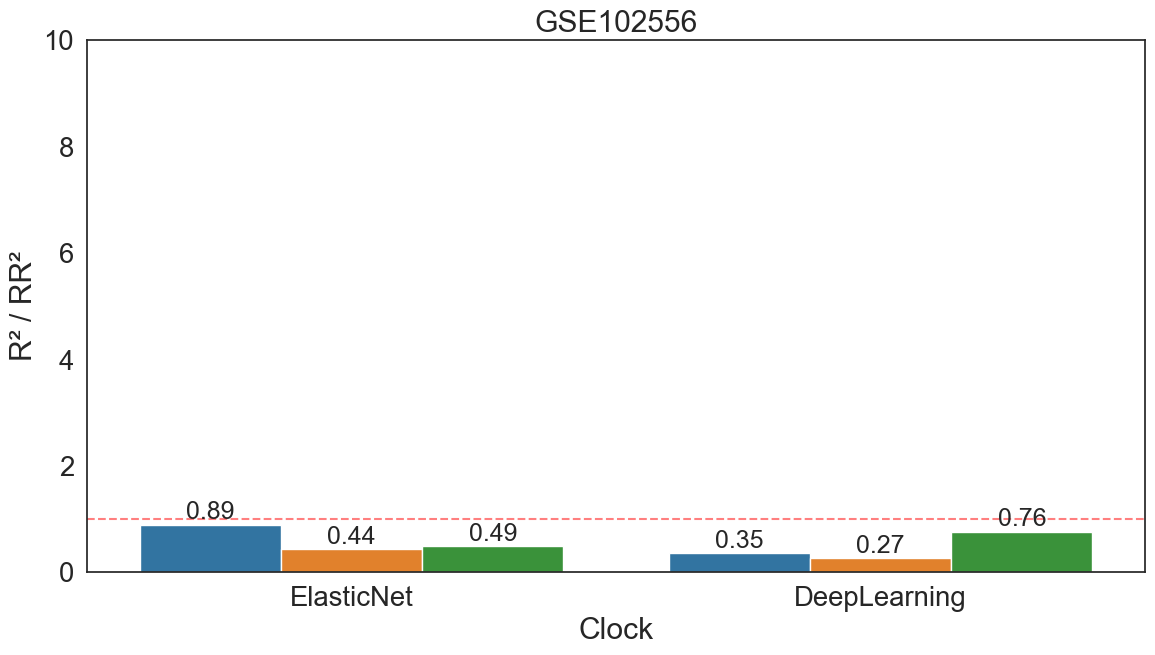

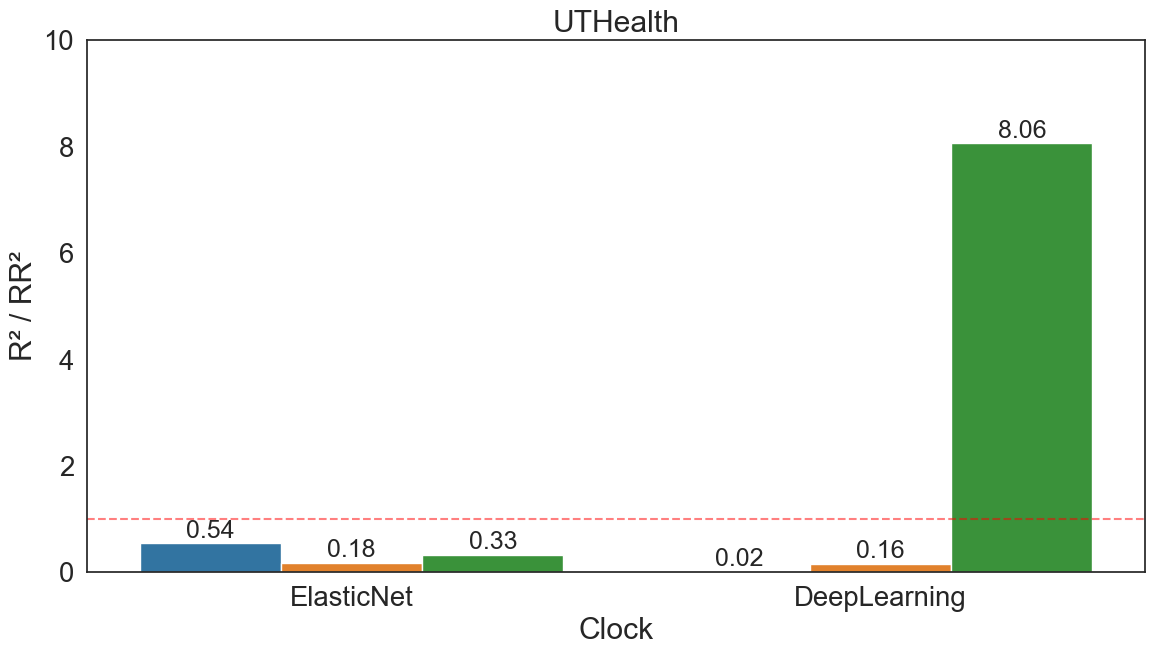

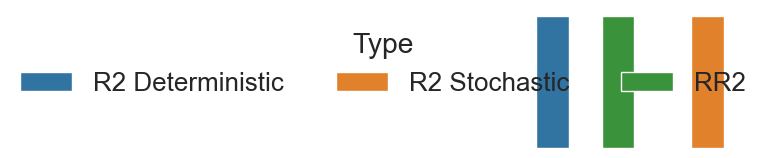

In [3]:
# ------------------------------
# Function to estimate variance explained
# ------------------------------
def build_r2_rr2_df(df, cohort_name):
    results = []

    clocks = ["ElasticNet", "DeepLearning"]

    for clock in clocks:
        det = df[f"Predicted_{clock}"]
        sto = df[f"Predicted_{clock}_Stochastic"]
        actual = df["Actual_Age"]

        # R² deterministic = squared Pearson correlation
        r2_det = actual.corr(det) ** 2
        results.append({"Clock": clock, "Type": "R2 Deterministic", "Value": r2_det, "Cohort": cohort_name})

        # R² stochastic
        r2_sto = actual.corr(sto) ** 2
        results.append({"Clock": clock, "Type": "R2 Stochastic", "Value": r2_sto, "Cohort": cohort_name})

        # RR² = squared correlation between deterministic and stochastic predictions
        rr2 = r2_sto/r2_det 
        results.append({"Clock": clock, "Type": "RR2", "Value": rr2, "Cohort": cohort_name})

    return pd.DataFrame(results)

# ------------------------------
# Function to plot and save without legend, with bar annotations
# ------------------------------
def plot_r2_rr2_annotated(df_plot, filename):
    sns.set_style("white")
    sns.set_context("notebook", font_scale=1.8)
    plt.figure(figsize=(12,7))
    
    ax = sns.barplot(
        data=df_plot, x="Clock", y="Value", hue="Type", 
        palette=["tab:blue", "tab:orange", "tab:green"], errorbar=None, dodge=True
    )
    
    plt.axhline(1, color="red", linestyle="--", alpha=0.5)
    plt.ylabel("R² / RR²")
    plt.xlabel("Clock")
    plt.title(f"{df_plot['Cohort'][0]}")
    plt.ylim(0, 10)
    plt.legend([],[], frameon=False)  # remove legend

    # Annotate using actual DataFrame values only
    clocks = df_plot["Clock"].unique()
    types = df_plot["Type"].unique()
    n_types = len(types)
    bar_width = 0.8 / n_types  # approximate width of each dodged bar

    for i, row in df_plot.iterrows():
        clock_idx = list(clocks).index(row["Clock"])
        type_idx = list(types).index(row["Type"])
        x_pos = clock_idx - 0.4 + bar_width/2 + type_idx*bar_width
        y_pos = row["Value"]
        ax.text(x_pos, y_pos + 0.01, f"{y_pos:.2f}", ha='center', va='bottom', fontsize=18)

    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    plt.show()

# ------------------------------
# Create dummy legend figure
# ------------------------------
def save_legend(filename):
    sns.set_style("white")
    sns.set_context("notebook", font_scale=1.7)
    
    # Create a small dummy dataframe
    dummy = pd.DataFrame({
        "Clock": ["ElasticNet", "DeepLearning", "ElasticNet"],
        "Value": [1, 1, 1],
        "Type": ["R2 Deterministic", "R2 Stochastic", "RR2"]
    })
    
    plt.figure(figsize=(6,2))
    ax = sns.barplot(data=dummy, x="Clock", y="Value", hue="Type", 
                     palette=["tab:blue", "tab:orange", "tab:green"], dodge=True)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title="Type", frameon=False, ncol=3)
    
    plt.axis("off")  # remove axes
    plt.tight_layout()
    plt.savefig(filename, dpi=600)
    plt.show()

# ------------------------------
# Plot and save each cohort separately without legend
# ------------------------------
df_gse_plot = build_r2_rr2_df(gse, "GSE102556")
df_uth_plot = build_r2_rr2_df(uth, "UTHealth")
plot_r2_rr2_annotated(df_gse_plot, "01R2_RR2_GSE102556_no_legend.pdf")
plot_r2_rr2_annotated(df_uth_plot, "01R2_RR2_UTHealth_no_legend.pdf")

# ------------------------------
# Save a separate legend figure
# ------------------------------
save_legend("01R2_RR2_legend.pdf")